In [3]:
print("hallow world")

hallow world


In [139]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from datetime import datetime, timedelta, time
import os
import os
import sys
import pandas as pd
from typing import List, Dict, Optional
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
import random
import re

warnings.filterwarnings("ignore")
import plotly.express as px

In [136]:
dataset_path = r'C:\Users\TPWODL\New folder_Content\AutonomousDataAnalystAgent\data\raw_path\x_data.xlsx'

In [137]:
new_df = pd.read_excel(r'C:\Users\TPWODL\New folder_Content\AutonomousDataAnalystAgent\data\raw_path\x_data.xlsx')

In [138]:
new_df.shape

(32873, 34)

In [141]:
def get_remarks_df(df):
    """
    Process DataFrame to extract and flag specific patterns from REMARKS column.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame containing complaint/tweet data
        
    Returns:
    --------
    pd.DataFrame
        Filtered DataFrame with extracted features and flags
    """
    df = df.copy()
    
    # ========================================================================
    # DUPLICATE CASE: Extract 3-5 digit numbers, excluding certain patterns
    # ========================================================================
    duplicate_case = []
    
    for remarks in df['REMARKS']:
        if pd.isna(remarks):
            duplicate_case.append('NA')
            continue
        
        remarks_str = str(remarks)
        
        # Check if remarks contain excluded number patterns
        # 12-digit consumer number pattern
        if re.search(r'\b\d{12}\b', remarks_str):
            duplicate_case.append('NA')
            continue
        
        # 14-digit complaint number pattern
        if re.search(r'\b\d{14}\b', remarks_str):
            duplicate_case.append('NA')
            continue
        
        # 10-digit mobile number pattern
        if re.search(r'\b\d{10}\b', remarks_str):
            duplicate_case.append('NA')
            continue
        
        # Extract 3-5 digit numbers only if no exclusion criteria met
        matches = re.findall(r'\b\d{3,5}\b', remarks_str)
        
        if matches:
            duplicate_case.append(', '.join(matches))
        else:
            duplicate_case.append('NA')
    
    # Create the Duplicate Case column
    df['Duplicate Case'] = duplicate_case
    
    # ========================================================================
    # APPRECIATION TWEET: Extract and normalize mentions
    # ========================================================================
    df['Appreciation Tweet'] = (
        df['REMARKS']
        .astype(str)
        .str.findall(r'(?i)\bappreciation\s*tweet\b')
        .apply(lambda x: 'Appreciation Tweet' if x else 'NA')
    )
    
    # ========================================================================
    # AWAITED CONSUMER ID: Flag mentions of awaited consumer/details/response
    # ========================================================================
    df['Awaited Consumer Id'] = (
        df['REMARKS']
        .astype(str)
        .str.contains(
            r'(?i)\b(awaited\s*consumer|details?|exacts?|response?s?|id|asked|ask)\b',
            regex=True,
            na=False
        )
        .map({True: 'Yes', False: 'No'})
        .fillna('NA')
    )
    
    # ========================================================================
    # X USER ID: Extract Twitter/X username from URL
    # ========================================================================
    df['X User Id'] = (
        df['TWEET/LINK']
        .astype(str)
        .str.extract(r'(?:twitter\.com|x\.com)/([^/]+)/', expand=False)
    )
    
    df['X User Id'] = (
        df['X User Id']
        .apply(lambda x: '@' + x if pd.notna(x) and x != 'nan' and x else 'NA')
    )
    
    # ========================================================================
    # STREETLIGHT AND NOT TPWODL: Flag streetlight issues outside TPWODL
    # jurisdiction or containing location/jurisdiction keywords
    # ========================================================================
    df['Streetlight And Not TPWODL'] = (
        (
            df['REMARKS']
            .astype(str)
            .str.contains(r'(?i)\bstreetlight(s)?\b', regex=True, na=False) &
            ~df['REMARKS']
            .astype(str)
            .str.contains(r'(?i)\bTPWODL\b', regex=True, na=False)
        )
        |
        df['REMARKS']
        .astype(str)
        .str.contains(
            r'(?i)\b(not\s+related|dist|jurisdiction|jurisdictions|districts?|'
            r'not\s+under|not\s+coming|under|bhubaneswar|khordha|balasore|city|'
            r'angul|dhenkanal|boudh|koraput|nayagarh|ganjam|mayurbhanj|'
            r'nabarangpur|kandhamal|cuttack)\b',
            regex=True,
            na=False
        )
    )
    
    df['Streetlight And Not TPWODL'] = (
        df['Streetlight And Not TPWODL']
        .map({True: 'Yes', False: 'No'})
        .fillna('No')
    )
    
    # ========================================================================
    # CALL INITIATED CONSUMERS: Flag mentions of callback done
    # ========================================================================
    df['Call Initiated Consumers'] = (
        df['REMARKS']
        .astype(str)
        .str.contains(
            r'(?i)\b(call\s*back\s*done|callback\s*done|callcack\s*done)\b',
            regex=True,
            na=False
        )
        .map({True: 'Yes', False: 'No'})
        .fillna('NA')
    )
    
    # ========================================================================
    # ELEPHANT MOVEMENT: Flag mentions of elephant-related issues
    # ========================================================================
    df['Elephant Movement'] = (
        df['REMARKS']
        .astype(str)
        .str.contains(
            r'(?i)\b(elephant\s*movement|elephan\s*movement|movementum|elephant)\b',
            regex=True,
            na=False
        )
        .map({True: 'Yes', False: 'No'})
        .fillna('NA')
    )
    
    # ========================================================================
    # MAILED SENT: Flag mentions of email/mail communication
    # ========================================================================
    df['Mailed Sent'] = (
        df['REMARKS']
        .astype(str)
        .str.contains(
            r'(?i)\b(mailed|mail|mails|email|emailing)\b',
            regex=True,
            na=False
        )
        .map({True: 'Yes', False: 'No'})
        .fillna('NA')
    )
    
    # ========================================================================
    # SELECT AND RETURN SPECIFIC COLUMNS
    # ========================================================================
    remarks_filter_df = df[[
        'SL.NO',
        'DATE',
        'DIVISION',
        'CIRCLE',
        'COMPLAINT TYPE',
        'REMARKS',
        'TWEET/LINK',
        'COMPLAINANT NAME',
        'Duplicate Case',
        'Appreciation Tweet',
        'Awaited Consumer Id',
        'X User Id',
        'Streetlight And Not TPWODL',
        'Call Initiated Consumers',
        'Elephant Movement',
        'Mailed Sent'
    ]]
    
    return remarks_filter_df

In [142]:
remarks_df = get_remarks_df(new_df)

In [143]:
remarks_df.columns

Index(['SL.NO', 'DATE', 'DIVISION', 'CIRCLE', 'COMPLAINT TYPE', 'REMARKS',
       'TWEET/LINK', 'COMPLAINANT NAME', 'Duplicate Case',
       'Appreciation Tweet', 'Awaited Consumer Id', 'X User Id',
       'Streetlight And Not TPWODL', 'Call Initiated Consumers',
       'Elephant Movement', 'Mailed Sent'],
      dtype='object')

In [144]:


# Check value counts for all new columns
print("=" * 50)
print("VALUE COUNTS FOR ALL COLUMNS")
print("=" * 50)

columns_to_check = [
    'Duplicate Case', 
    'Appreciation Tweet', 
    'Awaited Consumer Id',
    'X User Id', 
    'Streetlight And Not TPWODL',
    'Call Initiated Consumers', 
    'Elephant Movement', 
    'Mailed Sent'
]

for col in columns_to_check:
    print(f"\n{col}:")
    print(remarks_df[col].value_counts())
    print("-" * 50)

VALUE COUNTS FOR ALL COLUMNS

Duplicate Case:
Duplicate Case
NA                   26322
8505                    27
18325, 6920             27
17794, 6287, 2018       24
2022                    20
                     ...  
19403, 8653              1
32802                    1
32771                    1
32707                    1
32703                    1
Name: count, Length: 2910, dtype: int64
--------------------------------------------------

Appreciation Tweet:
Appreciation Tweet
NA                    29429
Appreciation Tweet     3444
Name: count, dtype: int64
--------------------------------------------------

Awaited Consumer Id:
Awaited Consumer Id
No     27632
Yes     5241
Name: count, dtype: int64
--------------------------------------------------

X User Id:
X User Id
NA                  7593
@rkb97official       593
@Bikramkesh4707      453
@akshya_patra        433
@CharubalaB          364
                    ... 
@Kanheimishra          1
@swarupkumarmis3       1
@bajrangsul

In [145]:
remarks_df.columns

Index(['SL.NO', 'DATE', 'DIVISION', 'CIRCLE', 'COMPLAINT TYPE', 'REMARKS',
       'TWEET/LINK', 'COMPLAINANT NAME', 'Duplicate Case',
       'Appreciation Tweet', 'Awaited Consumer Id', 'X User Id',
       'Streetlight And Not TPWODL', 'Call Initiated Consumers',
       'Elephant Movement', 'Mailed Sent'],
      dtype='object')

In [146]:
duplicate_case_count = len(remarks_df[remarks_df["Duplicate Case"] != "NA"])

In [147]:
appreciation_tweet_count = len(remarks_df[remarks_df["Appreciation Tweet"] != "NA"])

In [148]:
X_User_Id_count = len(remarks_df[remarks_df["X User Id"] != "NA"])

In [63]:
X_User_Id_dm_count = len(remarks_df.index) - X_User_Id_count

In [ ]:
not_related_tpwodl_count  = len(remarks_df[remarks_df["Streetlight And Not TPWODL"] != "No"])

In [77]:
call_done_consumes_count  = len(remarks_df[remarks_df["Call Initiated Consumers"] != "No"])

In [87]:
elephant_movement_count  = len(remarks_df[remarks_df["Elephant Movement"] != "No"])

In [89]:
email_sent_count  = len(remarks_df[remarks_df["Mailed Sent"] != "No"])

In [97]:
def get_remarks_counts(remarks_df):
    """
    Generate a summary count DataFrame from remarks_df.
    
    Parameters:
    -----------
    remarks_df : pandas.DataFrame
        DataFrame containing remarks with various categorization columns
    
    Returns:
    --------
    pandas.DataFrame
        Summary DataFrame with categories and their counts
    """
    import pandas as pd
    
    counts_data = {
        'Category': [
            'Duplicate Cases',
            'Appreciation Tweets',
            'X User IDs Available',
            'X User IDs Not Available (DM)',
            'Not Related to TPWODL',
            'Calls Initiated to Consumers',
            'Elephant Movement Cases',
            'Emails Sent'
        ],
        'Count': [
            (remarks_df["Duplicate Case"] != "NA").sum(),
            (remarks_df["Appreciation Tweet"] != "NA").sum(),
            (remarks_df["X User Id"] != "NA").sum(),
            (remarks_df["X User Id"] == "NA").sum(),
            (remarks_df["Streetlight And Not TPWODL"] != "No").sum(),
            (remarks_df["Call Initiated Consumers"] != "No").sum(),
            (remarks_df["Elephant Movement"] != "No").sum(),
            (remarks_df["Mailed Sent"] != "No").sum()
        ]
    }
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(counts_data)
    
    # Add total records row
    total_row = pd.DataFrame({
        'Category': ['Total Data Length Records'],
        'Count': [len(remarks_df)]
    })
    
    summary_df = pd.concat([summary_df, total_row], ignore_index=True)
    
    return summary_df




In [98]:
remarks_summary_df = get_remarks_counts(remarks_df)

In [99]:
remarks_summary_df

,Category,Count
0,Duplicate Cases,6578
1,Appreciation Tweets,3444
2,X User IDs Available,25280
3,X User IDs Not Available (DM),7593
4,Not Related to TPWODL,724
5,Calls Initiated to Consumers,953
6,Elephant Movement Cases,129
7,Emails Sent,710
8,Total Data Length Records,32873


In [ ]:
remarks_df

In [101]:
x_username =remarks_df['COMPLAINANT NAME'].str.title().value_counts()

In [102]:
x_username

COMPLAINANT NAME
Mr. Rajesh Kumar Bagarti    232
Mr.Rajesh Kumar Bagarti     178
Mr. Deepak Kumar Sarangi    168
Mr. Bikramkesh4707          162
Mr. Jyotiranjan Padhan      155
                           ... 
Mr. Aadesh Jaiswal            1
Mr. Satyajit Sahoo            1
Mr.Vaqas                      1
Mr. Akash Gupta               1
Mr. Sahil                     1
Name: count, Length: 6961, dtype: int64

In [117]:
userid_counts = ( remarks_df['X User Id'] .astype(str).str.strip() .replace({'na': np.nan, 'Na': np.nan, 'NA': np.nan}) .dropna() .str.title() .value_counts() )

In [118]:
userid_counts

X User Id
@Rkb97Official      593
@Bikramkesh4707     453
@Akshya_Patra       433
@Charubalab         364
@Bhagatsingh_07     344
                   ... 
@Akanhar18672         1
@Satyaka81197782      1
@Anonymous2511_       1
@Mahakur1202          1
@Choudhury94          1
Name: count, Length: 3481, dtype: int64

In [119]:
duplicate_case_unique = remarks_df['Duplicate Case'].str.strip().str.lower().value_counts().drop(labels='na')

In [120]:
duplicate_case_unique

Duplicate Case
8505                 27
18325, 6920          27
17794, 6287, 2018    24
8724                 20
2022                 20
                     ..
32862                 1
1468                  1
600                   1
2023, 2024            1
612                   1
Name: count, Length: 2922, dtype: int64

In [96]:
remarks_df.columns

Index(['SL.NO', 'DATE', 'DIVISION', 'CIRCLE', 'COMPLAINT TYPE', 'REMARKS',
       'TWEET/LINK', 'COMPLAINANT NAME', 'Duplicate Case',
       'Appreciation Tweet', 'Awaited Consumer Id', 'X User Id',
       'Streetlight And Not TPWODL', 'Call Initiated Consumers',
       'Elephant Movement', 'Mailed Sent'],
      dtype='object')

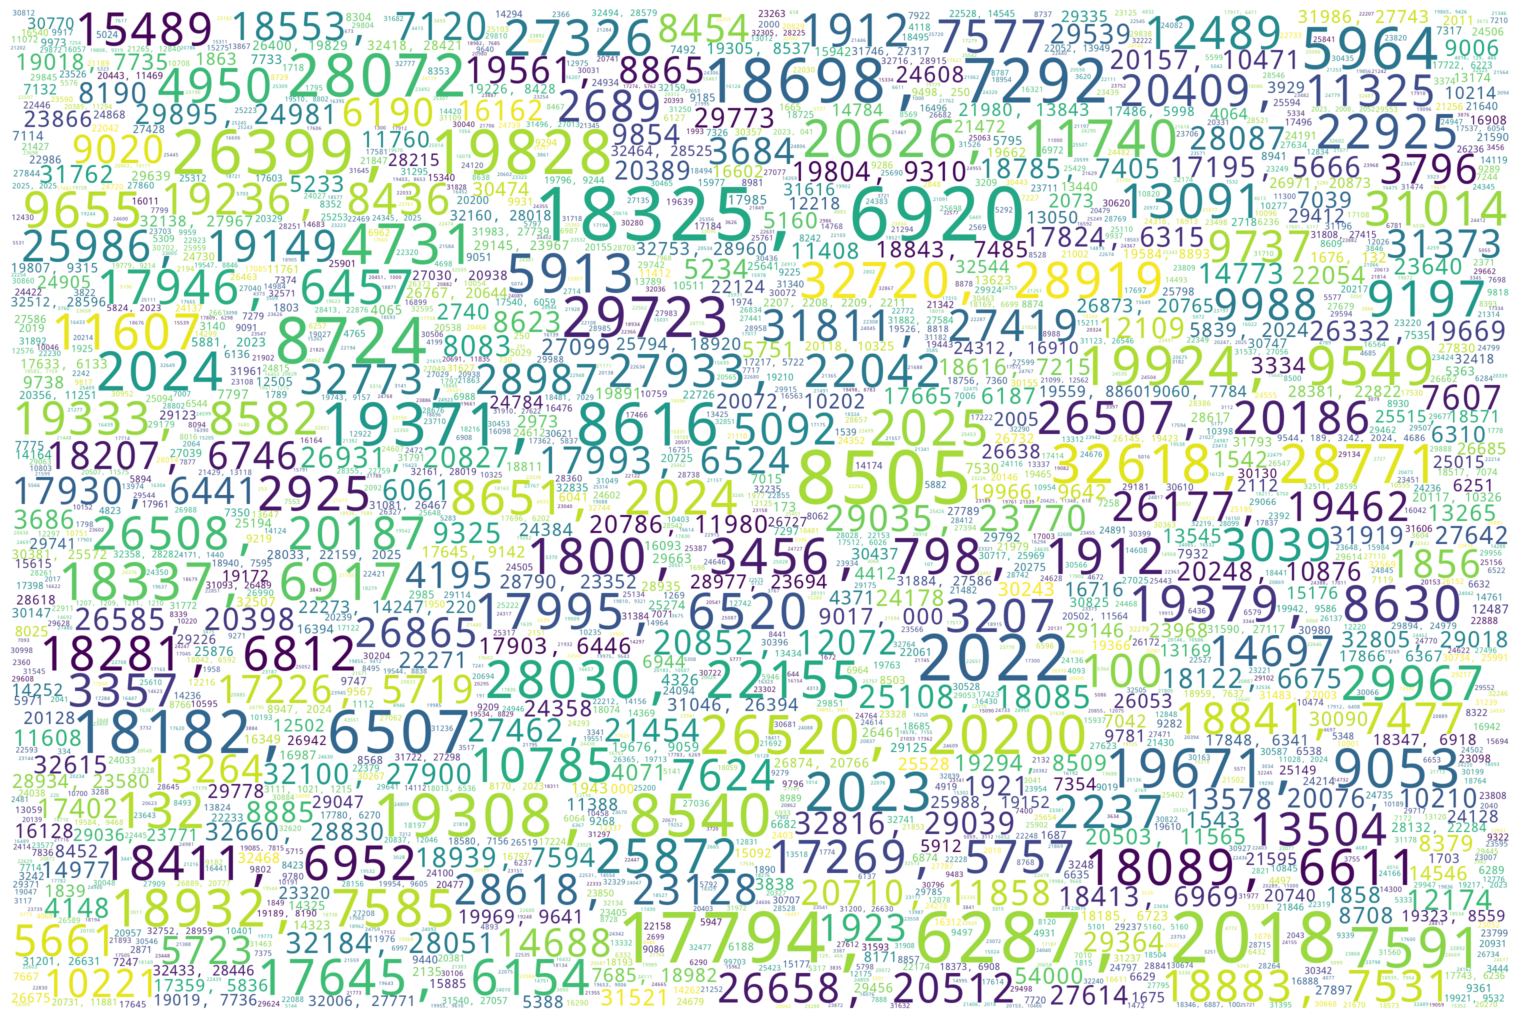

In [134]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create word cloud optimized to show maximum words horizontally
wordcloud = WordCloud(
    width=3000, 
    height=2000,
    background_color='white',
    colormap='viridis',
    relative_scaling=0.5,      # Changed: less size variation = more words fit
    min_font_size=8,           # Changed: smaller minimum = more words included
    max_font_size=150,         # Changed: smaller maximum = more space for other words
    font_step=1,
    random_state=None,
    prefer_horizontal=1.0,     # Added: all words horizontal
    max_words=2000,            # Added: increase max words displayed
    collocations=False,        # Added: avoid repeat phrases
    margin=2,                  # Added: reduce margin for more space
    include_numbers=True       # Added: include numbers if in your data
).generate_from_frequencies(duplicate_case_unique)

# Display
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

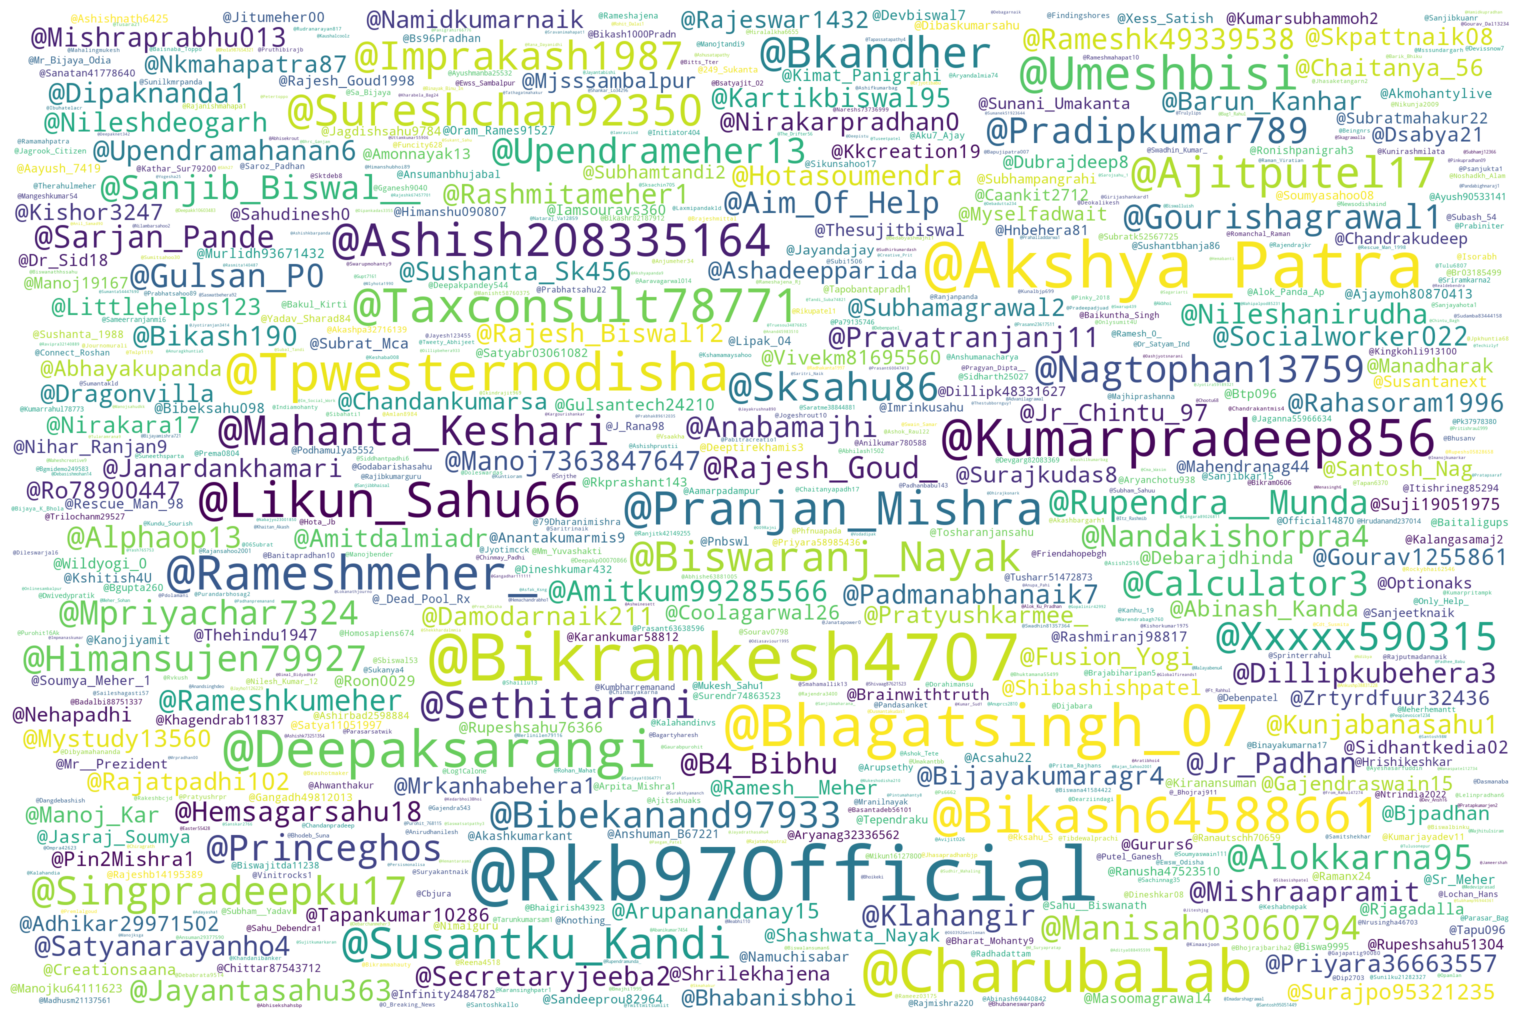

In [133]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create word cloud optimized to show maximum words
wordcloud = WordCloud(
    width=3000, 
    height=2000,
    background_color='white',
    colormap='viridis',
    relative_scaling=0.5,      # Changed: less size variation = more words fit
    min_font_size=8,           # Changed: smaller minimum = more words included
    max_font_size=150,         # Changed: smaller maximum = more space for other words
    font_step=1,
    random_state=None,
    prefer_horizontal=1.0,     # All words horizontal
    max_words=2000,            # Added: increase max words displayed (default is 200)
    collocations=False,        # Added: avoid repeat phrases
    margin=2,                  # Added: reduce margin for more space
    include_numbers=True       # Added: include numbers if in your data
).generate_from_frequencies(userid_counts)

# Display
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()